<a href="https://colab.research.google.com/github/plmacedo/DSW1/blob/master/Filtros_nao_lineares.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  **Filtros não Lineares**
Projeto 1 - Processamento Digital de Imagens

Autores:  
Vinícius Ferreira Araújo 832915

Maurício Alonzo 834204

Pedro Leal Macedo 832768

link do drive para botar imagens: https://drive.google.com/drive/folders/1gSsKSVcOuSnK7NU0b_hus-6d0uyp4WkQ?usp=sharing

No nosso trabalho estamos implemtentando os filtros de Mediana e de média geométrica, considerados filtros de suavizacão não lineares e os comparando com o filtro de suavização linear mais popular, o filtro Gaussiano.

# Filtro Gaussiano:   

O filtro gaussiano é um filtro de normalização é definido pela equação
\begin{equation}
y(x) = \frac{1}{\sigma\sqrt{2\pi}}exp\left({-\frac{x^2 + y^2}{2\sigma^2}}\right)
\end{equation}


O que diferencia o filtro gaussiano de outros filtros lineares de suavização é justamente o peso diferente que ele dá a cada pixel. Portanto, ele se difere de outros filtros lineares como o filtro de média, que trata igualmente os pesos dos pixeis idependente da sua distância ao pixel central.

E σ é o parametro que ajustamos a fim de determinhar o quão íngreme é a curva, ou seja, o quanto levaremos em consideração pixeis mais distantes do centro. Quanto maior o σ mais suave é a curva e mais os pixeis distantes são levados em conta.


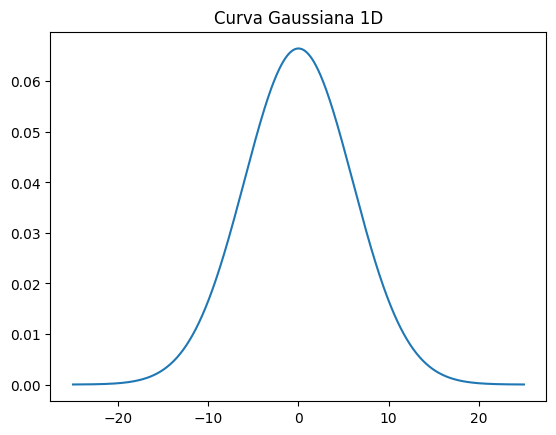

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import convolve as sp_convolve


sigma = 6 # desvio padrão da função
x = np.linspace(-5*5, 5*5, 1000)
y = np.exp(-x**2/(2*sigma**2))
y = y/(sigma*np.sqrt(2*np.pi))
plt.title("Curva Gaussiana 1D")
plt.plot(x, y) #plotando função gaussiana

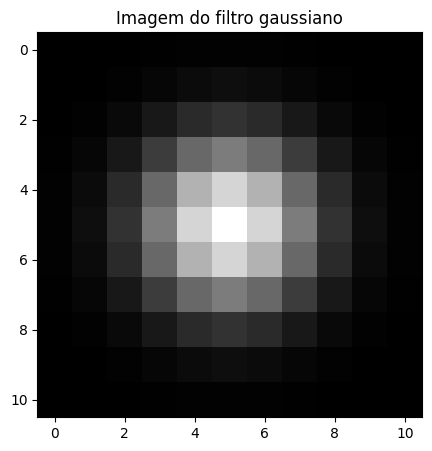

In [ ]:
def gaussian_filter_2d(filter_size):
    #Função gera o filtro que será aplicado na imagem alvo

    sigma = filter_size/6. # garante que a curva caiba no filtro

    x_vals = np.linspace(-3*sigma, 3*sigma, filter_size)
    y_vals = x_vals.copy()

    matrix = np.zeros((filter_size, filter_size))
    for row in range(filter_size):
        x = x_vals[row]
        for col in range(filter_size):
            y = y_vals[col]
            matrix[row, col] = np.exp(-(x**2+y**2)/(2*sigma**2)) #aplica o filtro gaussiano
    matrix = matrix/np.sum(matrix) #normaliza e garante que soma da matriz eh 1

    return matrix

#AJUSTE DO FILTRO GAUSSIANO
w = gaussian_filter_2d(11)
plt.figure(figsize=[5,5])
plt.title("Imagem do filtro gaussiano")
plt.imshow(w, "gray")

In [ ]:
def convolve(img, w):
    # Implementa  convolução para aplicar o filtro gaussiano
    #utiliza zero-padding para preencher partes de "fora" da imagem com
    return sp_convolve(img, w, mode="same")


w = gaussian_filter_2d(19)

img = plt.imread("./drive/MyDrive/IMAGENS_PDI/isthisit.tiff")
img_filtered = convolve(img, w)

fig, ax = plt.subplots(1, 2, figsize=[8,4])
ax[0].imshow(img, "gray")
ax[0].set_title("Imagem original")
ax[1].imshow(img_filtered, "gray")
ax[1].set_title("Imagem filtrada")

FileNotFoundError: [Errno 2] No such file or directory: './drive/MyDrive/IMAGENS_PDI/isthisit.tiff'

# Filtro de Média geométrica:  

O diretório atual é: /content


# Filtro de Mediana   